### Problem 4
***

### a)

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Define the ticker. For each of the tickers I add the corresponding names. Changing some of the names.

tickers = {
    'AAPL': 'Apple',
    'AAL': 'American airlines',
    'TSLA': 'Tesla',
    'GC=F': 'Gold',
    'CL=F': 'Crude oil',
    # Also adding equinor last this time.
    'EQNR.OL': 'Equinor'
}

# Defining the start and end date for the data.
start_date = '2013-01-01'
end_date = '2023-01-01'

# Download historical data. Using a for loop that goes through all tickers, with start as start_date and end as end_date given. The ['Adj Close'] only gives the 
# Adjusted close column with the correct index.
data = {}
for ticker, name in tickers.items():
    data[name] = yf.download(ticker, start=start_date, end=end_date, ignore_tz=True)['Adj Close'].dropna()



[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [5]:
# First creating a dictionary
log_return = {}
# Then making a column for each of the assets with the correlated log returns for each day. 
for ticker, name in tickers.items():
    log_return[name] = np.log(data[name] / data[name].shift(1))

c:\ProgramData\Anaconda3\lib\site-packages\pandas\core\arraylike.py:397: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


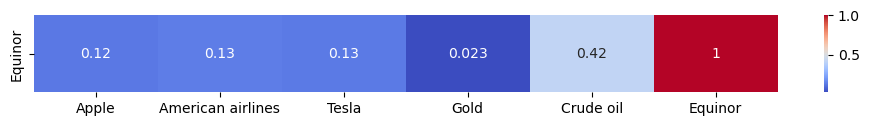

In [6]:
# Have to change the data to pandas dataframe to calculate the correlation. Calculating the correlation for all the values, but only 
# plotting the correlation with Equinor.
log_return = pd.DataFrame(log_return).dropna()
corr_matrix = log_return.corr()

# Using the last row of the matrix, because that is where Equinor is placed. 
plt.figure(figsize = (12,1) )
sns.heatmap(corr_matrix[-1:], annot=True, cmap = 'coolwarm')
plt.show()

##### We can see that the correlation is relatively low with the other assets for Equinor for the entire period. However, it does show that the correlation between Equinor and crude oil is a bit higher. This makes completely sense, since Equinor is a oil and gas company that makes more profit as the crude oil price increases. The correlation between Equinor and Equinor will always be equal to 1. 

***
### b)

##### Did the wrong thing first.

In [7]:
# # Creating the rolling average for 252 as days rolling for all values for each of the assets. Then creating the correlation matrix for 
# # these values. 
# # Days rolling
# dr = 252

# # Empty 
# rolling_average = {}

# # Creating a column in rolling_average that is the rolling mean of the data, with 252 as days rolling. 
# for ticker, name in tickers.items():
#     rolling_average[name] = data[name].rolling(dr).mean()


# # Doing the same as a); have to make it a pandas dataframe before doing the correlation. Then making a heatmap of the last row to find the 
# # correlation of the moving average of the last 252 days. 

# rolling_average = pd.DataFrame(rolling_average)
# corr_matrix_avg = rolling_average.corr()


# plt.figure(figsize = (12,1) )
# sns.heatmap(corr_matrix_avg[-1:], annot=True, cmap = 'coolwarm')
# plt.show()

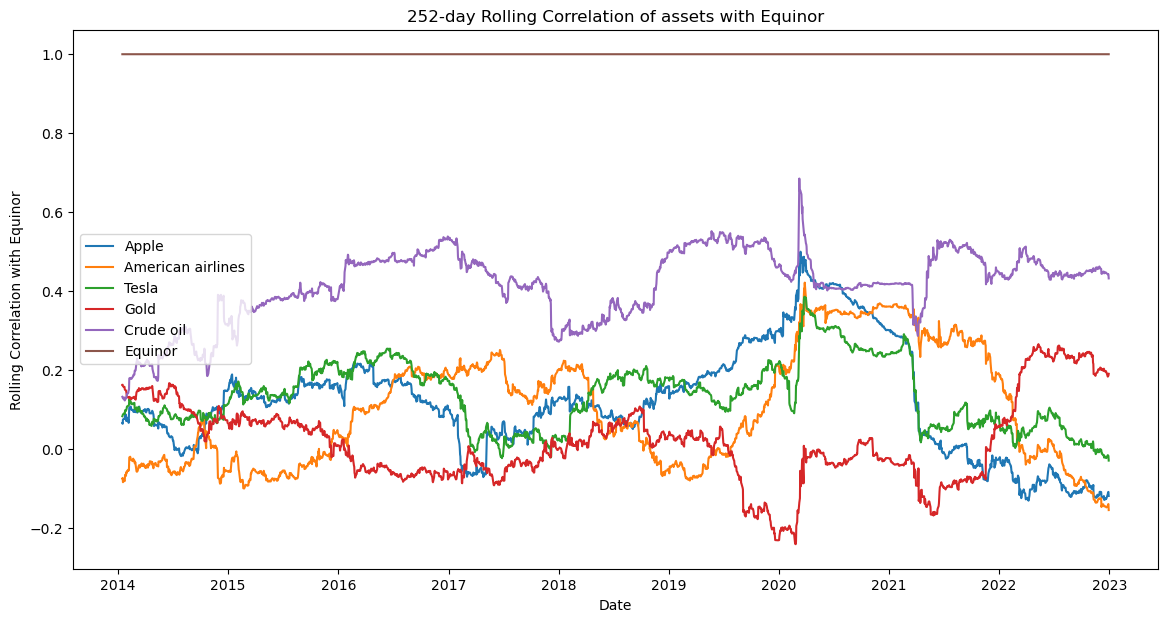

In [8]:
# Calculating the correlation of the rolling log return of the assets with the equinor asset.
rolling_corr = log_return.rolling(252).corr(log_return["Equinor"])


plt.figure(figsize=(14, 7))

# Plot each column
for col in rolling_corr.columns:
    plt.plot(rolling_corr.index, rolling_corr[col], label=col)

plt.legend()
plt.xlabel('Date')
plt.ylabel('Rolling Correlation with Equinor')
plt.title('252-day Rolling Correlation of assets with Equinor')
plt.show()



##### From the graph we can see that the correlation is kind of random going up and down. However, there is a big spike for all of the correlations in the start of 2020, which I would think comes from the corona virus situation. This made a lot of assets go down in value and would probably be the reason why they all spiked like this at that time. There is also some that will argue that the correlation in market downfall is higher, and we can see that by this spike. We can also see that some of the assets have a rolling correlation below zero for some time periods, and other time periods the correlation seems to be much higher. This means that one should look more at the later values than the correlation that was longer ago for more accurate estimates of the current correlation. 